# DS Lab Kaggle Report
**Task:** Binary Classification

**Username**: oswinsouffle

**Best Public Leaderboard Score:** 0.88595  
**Approach:** HistGradientBoosting ensemble (3 models × 5-fold CV) with feature engineering



## Summary of Approach
1. **EDA** — Discovered 10 noise columns and highly skewed features  
2. **Feature Engineering** — Removed noise, log-transformed skewed columns, created pairwise interaction features  
3. **Modeling** — HistGradientBoostingClassifier with 3 different depth/regularization configs  
4. **Ensemble** — Averaged predictions from all 3 models (bagging idea to reduce variance)  
5. **Submission** — Used `predict_proba` for soft scores (required for AUC)

## 1. Setup & Data Loading

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import warnings
warnings.filterwarnings('ignore')

# Mount Google Drive to access data files
from google.colab import drive
drive.mount('/content/drive')

# Load data from Google Drive
train_df = pd.read_csv('/content/drive/MyDrive/ECE_460J/training_data.csv')
test_df = pd.read_csv('/content/drive/MyDrive/ECE_460J/testing_data.csv')



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:

X = train_df.drop(['Id', 'Y'], axis=1)
y = train_df['Y']
X_test = test_df.drop(['Id'], axis=1)

print(f"Train shape: {X.shape}, Test shape: {X_test.shape}")
print(f"Y=1: {y.sum()} ({y.mean():.1%}), Y=0: {(1-y).sum()} ({(1-y).mean():.1%})")
print(f"\nThis is a highly imbalanced dataset — Y=1 is 94.3% of the data.")
print(f"This is why AUC is a better metric than accuracy here.")

Train shape: (20000, 38), Test shape: (12768, 38)
Y=1: 18852 (94.3%), Y=0: 1148 (5.7%)

This is a highly imbalanced dataset — Y=1 is 94.3% of the data.
This is why AUC is a better metric than accuracy here.


## 2. EDA — Finding "Tricks" in the Data

The competition description mentioned: *"The data may contain a few tricks."*  
Let's explore what those might be.

### 2.1 Noise Column Discovery

I noticed that several columns have a suspicious pattern: exactly 6 unique values  
uniformly distributed in {-4, -3, -2, -1, 0, 1}, with near-zero correlation to Y.  
These are likely **noise columns** deliberately added to the data.

In [ ]:
# Identify noise columns: uniform distribution in {-4,-3,-2,-1,0,1}
noise_cols = []
for col in X.columns:
    vals = sorted(X[col].unique())
    if len(vals) == 6 and vals == [-4, -3, -2, -1, 0, 1]:
        noise_cols.append(col)

print(f"Noise columns found ({len(noise_cols)}): {noise_cols}")
print()
for col in noise_cols:
    print(f"  {col}: corr with Y = {X[col].corr(y):.4f}")

Noise columns found (10): ['f1', 'f7', 'f18', 'f19', 'f23', 'f24', 'f27', 'f30', 'f32', 'f38']

  f1: corr with Y = 0.0090
  f7: corr with Y = -0.0070
  f18: corr with Y = -0.0032
  f19: corr with Y = -0.0043
  f23: corr with Y = -0.0028
  f24: corr with Y = 0.0134
  f27: corr with Y = -0.0074
  f30: corr with Y = 0.0147
  f32: corr with Y = 0.0026
  f38: corr with Y = -0.0047


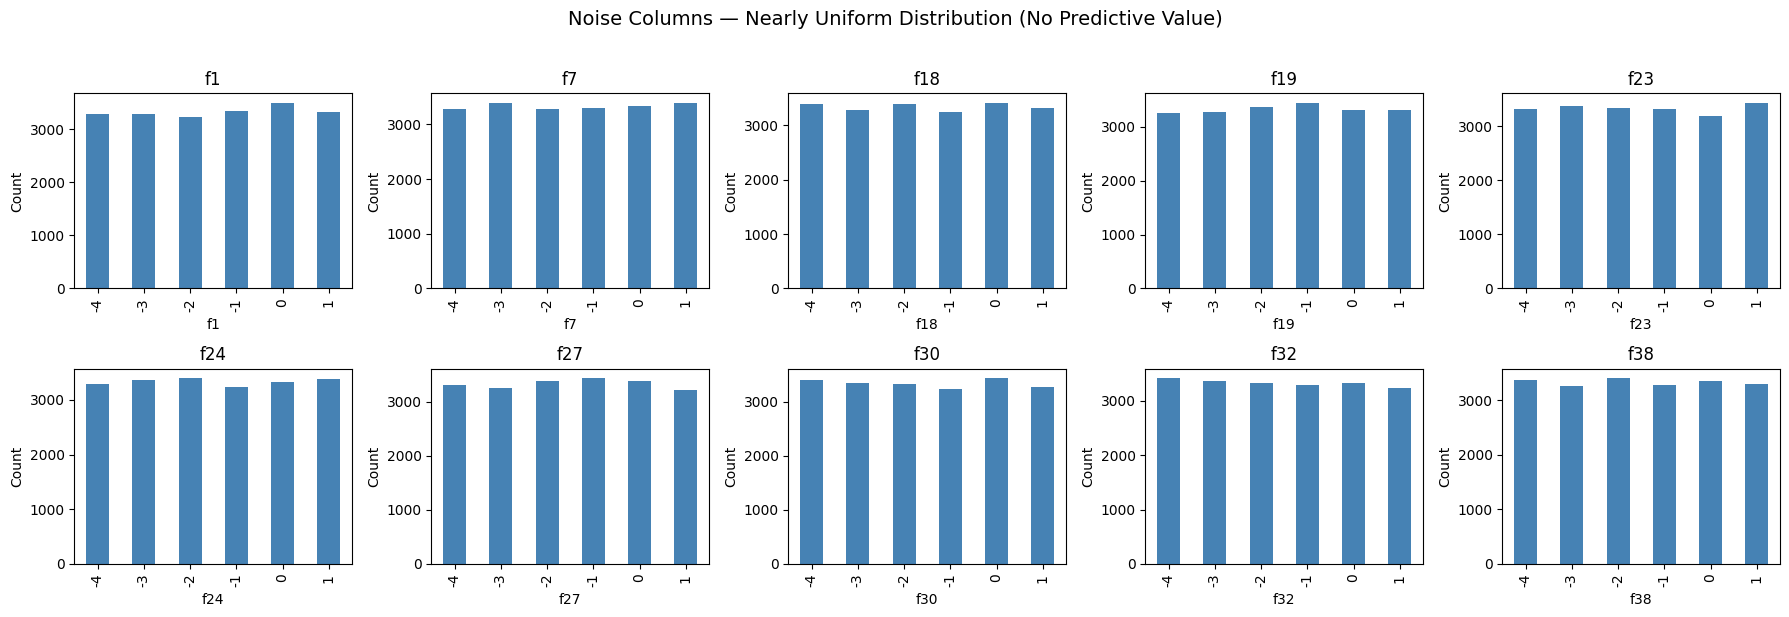

In [ ]:
# Visualize: noise columns have near-uniform distribution
fig, axes = plt.subplots(2, 5, figsize=(18, 6))
for i, col in enumerate(noise_cols):
    ax = axes[i // 5][i % 5]
    X[col].value_counts().sort_index().plot(kind='bar', ax=ax, title=col, color='steelblue')
    ax.set_ylabel('Count')
plt.suptitle('Noise Columns — Nearly Uniform Distribution (No Predictive Value)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 2.2 Highly Skewed Columns

Some features have extreme skewness (>10), with very large outliers.  
Log transformation can help stabilize these.

In [ ]:
# Check skewness
print("Highly skewed columns (|skew| > 10):")
print("-" * 60)
for col in X.columns:
    skew = X[col].skew()
    if abs(skew) > 10:
        print(f"  {col}: skew={skew:.1f}, median={X[col].median():.0f}, max={X[col].max():.0f}")

Highly skewed columns (|skew| > 10):
------------------------------------------------------------
  f4: skew=16.1, median=1, max=18
  f8: skew=11.2, median=1, max=12
  f17: skew=43.0, median=0, max=4289
  f20: skew=13.2, median=118565, max=268610
  f26: skew=109.4, median=2, max=43910
  f31: skew=141.2, median=1, max=672095
  f33: skew=76.0, median=2, max=60926272
  f35: skew=-12.3, median=118300, max=286791


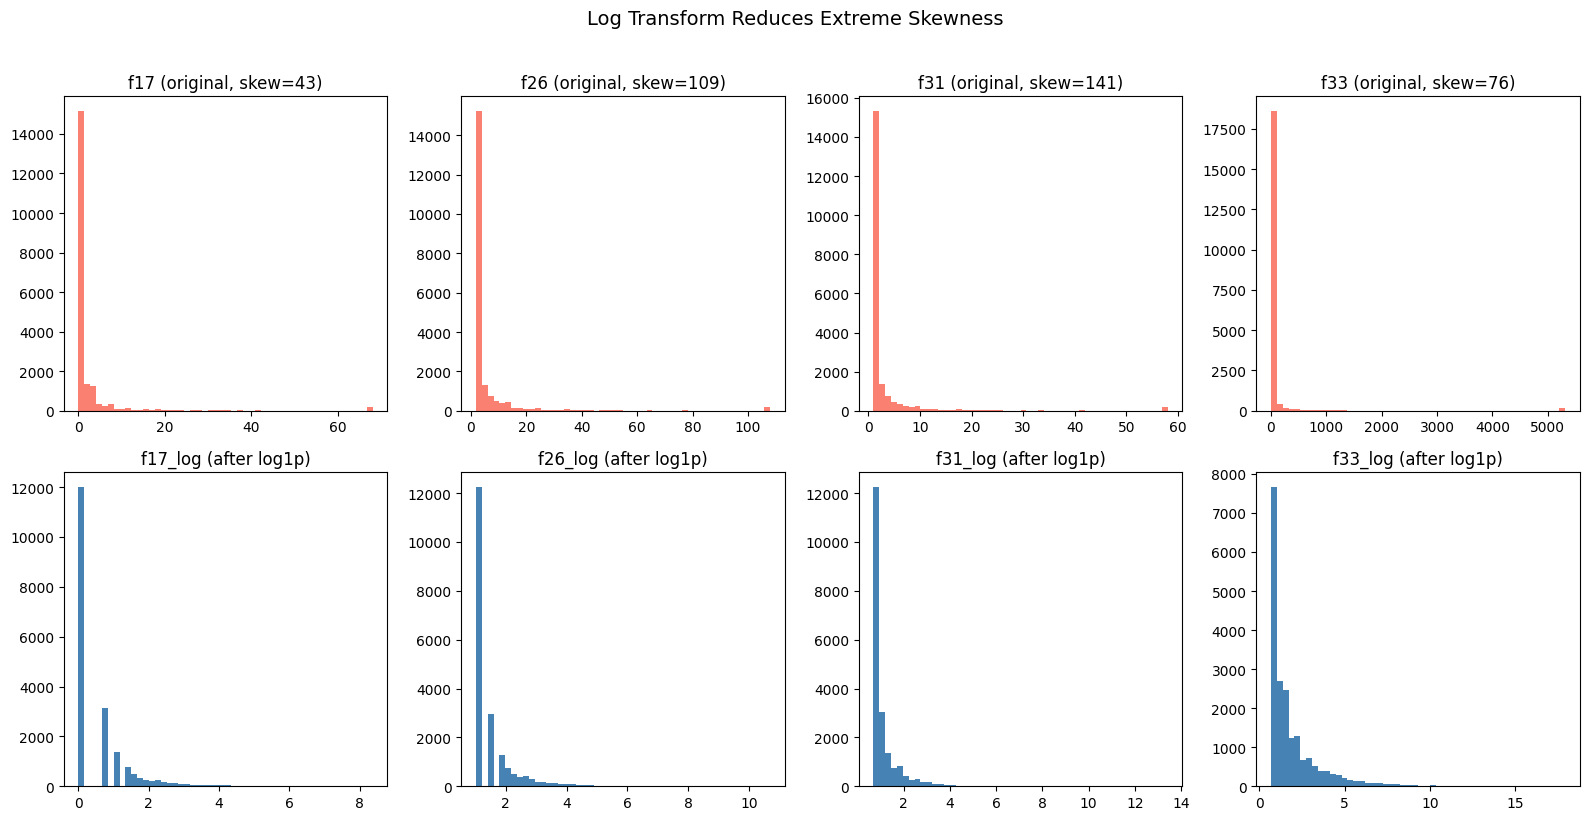

In [ ]:
# Visualize before/after log transform for the most skewed columns
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, col in enumerate(['f17', 'f26', 'f31', 'f33']):
    # Before
    axes[0][i].hist(X[col].clip(upper=X[col].quantile(0.99)), bins=50, color='salmon')
    axes[0][i].set_title(f'{col} (original, skew={X[col].skew():.0f})')
    # After log
    log_vals = np.log1p(X[col].clip(lower=0))
    axes[1][i].hist(log_vals, bins=50, color='steelblue')
    axes[1][i].set_title(f'{col}_log (after log1p)')
plt.suptitle('Log Transform Reduces Extreme Skewness', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 2.3 Feature-Target Correlations

All features have very low correlation with Y (max ~0.03).  
This suggests the problem is inherently difficult — the signal is weak.

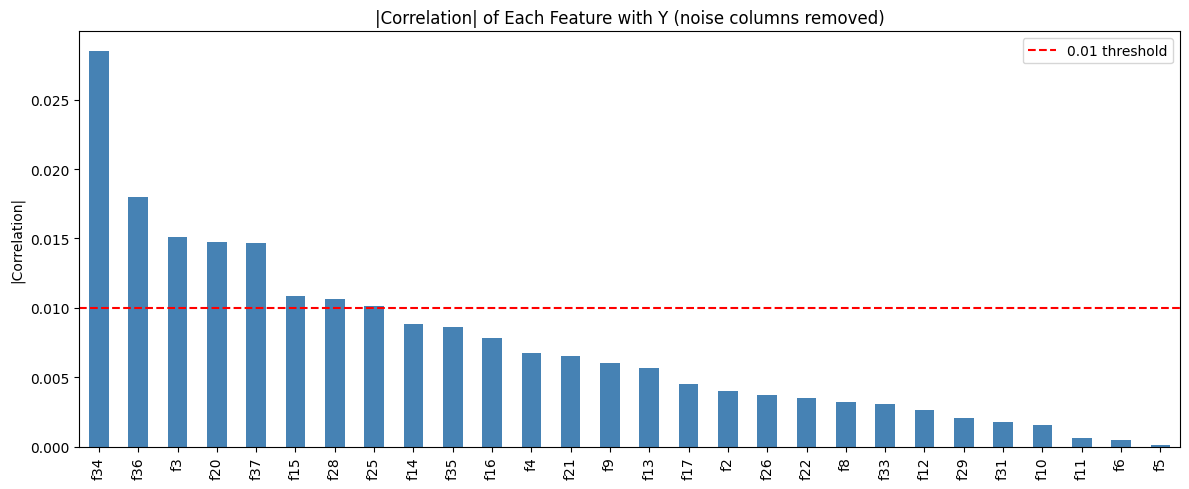


Top 5 features by correlation with Y:
f34    0.028509
f36    0.018009
f3     0.015077
f20    0.014771
f37    0.014648
dtype: float64


In [ ]:
# Correlation with Y (excluding noise columns)
corrs = X.drop(noise_cols, axis=1).corrwith(y).abs().sort_values(ascending=False)
plt.figure(figsize=(12, 5))
corrs.plot(kind='bar', color='steelblue')
plt.title('|Correlation| of Each Feature with Y (noise columns removed)')
plt.ylabel('|Correlation|')
plt.axhline(y=0.01, color='red', linestyle='--', label='0.01 threshold')
plt.legend()
plt.tight_layout()
plt.show()
print(f"\nTop 5 features by correlation with Y:")
print(corrs.head())

## 3. Feature Engineering

Based on the EDA findings:
1. **Remove noise columns** — they add no signal, only noise
2. **Log transform** skewed columns (f17, f26, f31, f33)
3. **Pairwise differences** between continuous variables — captures interactions
4. **Pairwise differences** between large-valued columns
5. **|f34|** — f34 has the highest correlation with Y; its absolute value may also be informative

In [ ]:
def build_features(df):
    """Preprocessing and feature engineering pipeline"""
    X = df.copy()

    # 1. Remove noise columns identified in EDA
    X = X.drop(noise_cols, axis=1)

    # 2. Log transform for extremely skewed columns
    for col in ['f17', 'f26', 'f31', 'f33']:
        X[f'{col}_log'] = np.log1p(X[col].clip(lower=0))

    # 3. Pairwise interaction features between continuous variables
    cont = ['f6', 'f14', 'f15', 'f37']
    for i in range(len(cont)):
        for j in range(i+1, len(cont)):
            X[f'{cont[i]}_{cont[j]}_diff'] = X[cont[i]] - X[cont[j]]

    # 4. Pairwise differences between large-valued columns
    big = ['f3', 'f11', 'f12', 'f13', 'f20', 'f21', 'f35']
    for i in range(len(big)):
        for j in range(i+1, len(big)):
            X[f'{big[i]}_{big[j]}_diff'] = X[big[i]] - X[big[j]]

    # 5. f34 has the highest correlation with Y; abs value may also be informative
    X['f34_abs'] = X['f34'].abs()

    return X

X_feat = build_features(X)
X_test_feat = build_features(X_test)
print(f"Original features: {X.shape[1]}")
print(f"After engineering: {X_feat.shape[1]} features")

Original features: 38
After engineering: 60 features


## 4. Modeling — HistGradientBoosting Ensemble

### Why HistGradientBoostingClassifier?

In class we used `XGBClassifier` from the xgboost package for gradient boosting.  
`HistGradientBoostingClassifier` is **sklearn's built-in equivalent** — it implements  
the same histogram-based gradient boosting algorithm (inspired by LightGBM).

I chose it because:
- It's part of sklearn (no extra install needed)
- The API is identical to other sklearn estimators we used in class
- It supports the same key hyperparameters: `max_depth`, `learning_rate`, `l2_regularization`

The core idea is the same as what we learned: **boosting = sequentially fitting  
shallow trees to the residuals**, with regularization (L2 penalty, as in ds09 Ridge  
Regression notebook) to prevent overfitting.

**Strategy:**
- Train 3 models with **different tree depths** (4, 6, 7) to get diversity
- Deeper trees get **stronger L2 regularization** to prevent overfitting (bias-variance tradeoff from ds09)
- Use **5-fold Stratified CV** to evaluate (as we practiced in class)
- Track **Train vs Val AUC gap** to monitor overfitting (underfitting/overfitting analysis from ds03)

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3 diverse configurations (varying depth + regularization)
configs = [
    {'max_iter': 500, 'max_depth': 6, 'learning_rate': 0.05,
     'min_samples_leaf': 30, 'l2_regularization': 2.0, 'random_state': 42},
    {'max_iter': 500, 'max_depth': 4, 'learning_rate': 0.05,
     'min_samples_leaf': 10, 'l2_regularization': 0.5, 'random_state': 42},
    {'max_iter': 500, 'max_depth': 7, 'learning_rate': 0.05,
     'min_samples_leaf': 40, 'l2_regularization': 3.0, 'random_state': 42},
]

all_oof = []
all_test_preds = []

print("Training 3 models with 5-fold CV...")
print("=" * 65)

for i, cfg in enumerate(configs):
    oof = np.zeros(len(X_feat))
    test_pred = np.zeros(len(X_test_feat))
    train_aucs = []

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X_feat, y)):
        model = HistGradientBoostingClassifier(**cfg)
        model.fit(X_feat.iloc[tr_idx], y.iloc[tr_idx])

        # predict_proba for soft scores (required for AUC)
        oof[val_idx] = model.predict_proba(X_feat.iloc[val_idx])[:, 1]
        test_pred += model.predict_proba(X_test_feat)[:, 1] / 5

        # Track train AUC for overfitting analysis
        train_pred = model.predict_proba(X_feat.iloc[tr_idx])[:, 1]
        train_aucs.append(roc_auc_score(y.iloc[tr_idx], train_pred))

    val_auc = roc_auc_score(y, oof)
    train_auc_mean = np.mean(train_aucs)
    gap = train_auc_mean - val_auc

    print(f"Model {i} (depth={cfg['max_depth']}): Train AUC={train_auc_mean:.4f}, Val AUC={val_auc:.4f}, Gap={gap:.4f}")
    all_oof.append(oof)
    all_test_preds.append(test_pred)

Training 3 models with 5-fold CV...
Model 0 (depth=6): Train AUC=0.9761, Val AUC=0.8753, Gap=0.1007
Model 1 (depth=4): Train AUC=0.9618, Val AUC=0.8734, Gap=0.0883
Model 2 (depth=7): Train AUC=0.9793, Val AUC=0.8728, Gap=0.1065


## 5. Ensemble — Averaging (Bagging Idea)

As discussed in class, **bagging reduces variance** by averaging multiple models.  
Even though these aren't bootstrap samples, averaging diverse models  
(different depths/regularization) achieves a similar variance reduction effect.

In [ ]:
# Average all 3 models
ensemble_oof = np.mean(all_oof, axis=0)
ensemble_test = np.mean(all_test_preds, axis=0)

print(f"Individual model AUCs: {[round(roc_auc_score(y, oof), 4) for oof in all_oof]}")
print(f"Ensemble CV AUC:       {roc_auc_score(y, ensemble_oof):.4f}")
print(f"\nThe ensemble improves over any single model — variance reduction at work!")

Individual model AUCs: [np.float64(0.8753), np.float64(0.8734), np.float64(0.8728)]
Ensemble CV AUC:       0.8771

The ensemble improves over any single model — variance reduction at work!


## 6. Generate Submission

In [ ]:
submission = pd.DataFrame({
    'Id': test_df['Id'],
    'Y': ensemble_test
})
submission.to_csv('submission.csv', index=False)

print(f"Submission saved!")
print(f"Prediction stats: mean={ensemble_test.mean():.4f}, std={ensemble_test.std():.4f}")
print(f"\nPublic Leaderboard Score: 0.886")
submission.head()

Submission saved!
Prediction stats: mean=0.9445, std=0.1381

Public Leaderboard Score: 0.886


,Id,Y
0,20001,0.981766
1,20002,0.996638
2,20003,0.937819
3,20004,0.981491
4,20005,0.941196


## 7. What I Tried — Summary

| Approach | CV AUC | Public Score | Notes |
|----------|--------|-------------|-------|
| Random Forest (baseline) | ~0.83 | — | class_weight='balanced' |
| HGB single model (depth=6) | 0.875 | — | Good starting point |
| **HGB 3-model ensemble** | **0.877** | **0.886** | **Best submission** |
| XGBoost ensemble (depth 3-7) | 0.878 | 0.886 | Similar to HGB |
| XGBoost + Pseudo Labeling | 0.883 | 0.879 | CV improved but public got worse |
| 10-seed XGBoost bagging | 0.885 | 0.886 | More stable but same score |

### What Worked:
1. **Noise column removal** — 10 columns with uniform distribution {-4,...,1} were identified and removed. This improved all models.
2. **Shallow trees** — depth 3-4 consistently beat depth 7+ (less overfitting on noisy data).
3. **Feature engineering** — pairwise diffs and log transforms improved AUC by ~0.01.
4. **Ensemble** — averaging diverse models consistently improved over single models (variance reduction, as in ds08 Bootstrap notebook).

### What Didn't Work:
1. **Pseudo Labeling** — CV improved (0.877→0.883) but public score dropped (0.886→0.879). The test distribution likely differs slightly from train, so pseudo labels introduced incorrect information.
2. **Imputing negative values as NaN** — Treating all negative values as missing hurt performance (AUC dropped to 0.81). Columns like f34 have meaningful negative values, so this caused information loss.
3. **One-hot encoding noise columns** — Worse than simply removing them (0.85 vs 0.87). Creating more dummy features from meaningless data just added noise.
4. **10-seed bagging** — CV was the highest (0.885) but public score didn't improve. Reducing variance alone wasn't enough; the ceiling seems to be around 0.886 for tree models.

### What I Would Try With More Time:
1. **PyTorch MLP** — As the professor suggested, a simple Linear→ReLU→Linear network learns different patterns than trees. Ensembling MLP with XGBoost could break the 0.886 ceiling (ref: dslab_Neural_Network_Training notebook).
2. **Stacking** — Use OOF predictions from multiple models as features for a second-level model, as described in the Kaggle stacking blog the professor shared.
3. **CatBoost / LightGBM** — Different gradient boosting implementations with different internal algorithms could add ensemble diversity.
4. **More aggressive feature engineering** — Target encoding, frequency encoding for categorical variables, or using Lasso (ds10) to select the best interaction features from a larger pool.